# Mutual Fund Analytics - Exploratory Data Analysis

In [55]:
# ==========================================
# Dataset Summary
# ==========================================

datasets = {
    "Fund Master": fund_df,
    "NAV History": nav_df,
    "Scheme Performance": scheme_df,
    "Investor Transactions": investor_df,
    "Monthly SIP": sip_df,
    "Category Inflows": category_df,
    "Portfolio Holdings": portfolio_df,
    "AUM": aum_df,
    "Industry Folio": folio_df,
    "Benchmark": benchmark_df
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

Fund Master
Rows    : 40
Columns : 15
NAV History
Rows    : 46000
Columns : 3
Scheme Performance
Rows    : 40
Columns : 20
Investor Transactions
Rows    : 32778
Columns : 13
Monthly SIP
Rows    : 48
Columns : 6
Category Inflows
Rows    : 144
Columns : 3
Portfolio Holdings
Rows    : 322
Columns : 8
AUM
Rows    : 90
Columns : 5
Industry Folio
Rows    : 21
Columns : 6
Benchmark
Rows    : 8050
Columns : 3


In [77]:
# ==========================================
# Display column names
# ==========================================

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.columns.tolist())
    print()

Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

Scheme Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'return_anomaly']

Investor Transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Monthly SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category Inflows
['mon

### 4. NAV Trend Analysis (2022–2026)

In [191]:
# Create output folder if it doesn't exist
os.makedirs("../outputs/charts", exist_ok=True)

fig.write_html("../outputs/charts/nav_trend.html")

fig.write_image(
    "../outputs/charts/nav_trend.png",
    width=1600,
    height=900
)

print("✅ NAV Trend chart saved successfully!")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [1]:
import kaleido
print(kaleido.__version__)

AttributeError: module 'kaleido' has no attribute '__version__'

In [4]:
import sys
print(sys.executable)

import subprocess
subprocess.run([sys.executable, "-m", "pip", "show", "kaleido"])

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe


CompletedProcess(args=['c:\\College notes\\Internship\\Bluestock Finetech Internship\\MutualFundAnalytics\\venv\\Scripts\\python.exe', '-m', 'pip', 'show', 'kaleido'], returncode=0)

In [ ]:
# Create output folder if it doesn't exist
os.makedirs("../outputs/charts", exist_ok=True)

# Save chart as HTML
fig.write_html("../outputs/charts/nav_trend.html")

# Save as PNG (requires kaleido)
try:
    fig.write_image("../outputs/charts/nav_trend.png", width=1600, height=900)
    print("✅ NAV trend chart saved as PNG.")
except Exception:
    print("⚠️ PNG export requires the 'kaleido' package.")
    print("Run: pip install kaleido")

NameError: name 'os' is not defined

In [22]:
# ==========================================
# NAV Trend Analysis
# ==========================================

# Convert date column to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Merge NAV with fund information
nav_plot = nav_df.merge(
    fund_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Keep only data from 2022 onwards
nav_plot = nav_plot[nav_plot["date"] >= "2022-01-01"]

print(nav_plot.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


## 5. AUM Growth by Fund House (2022–2025)

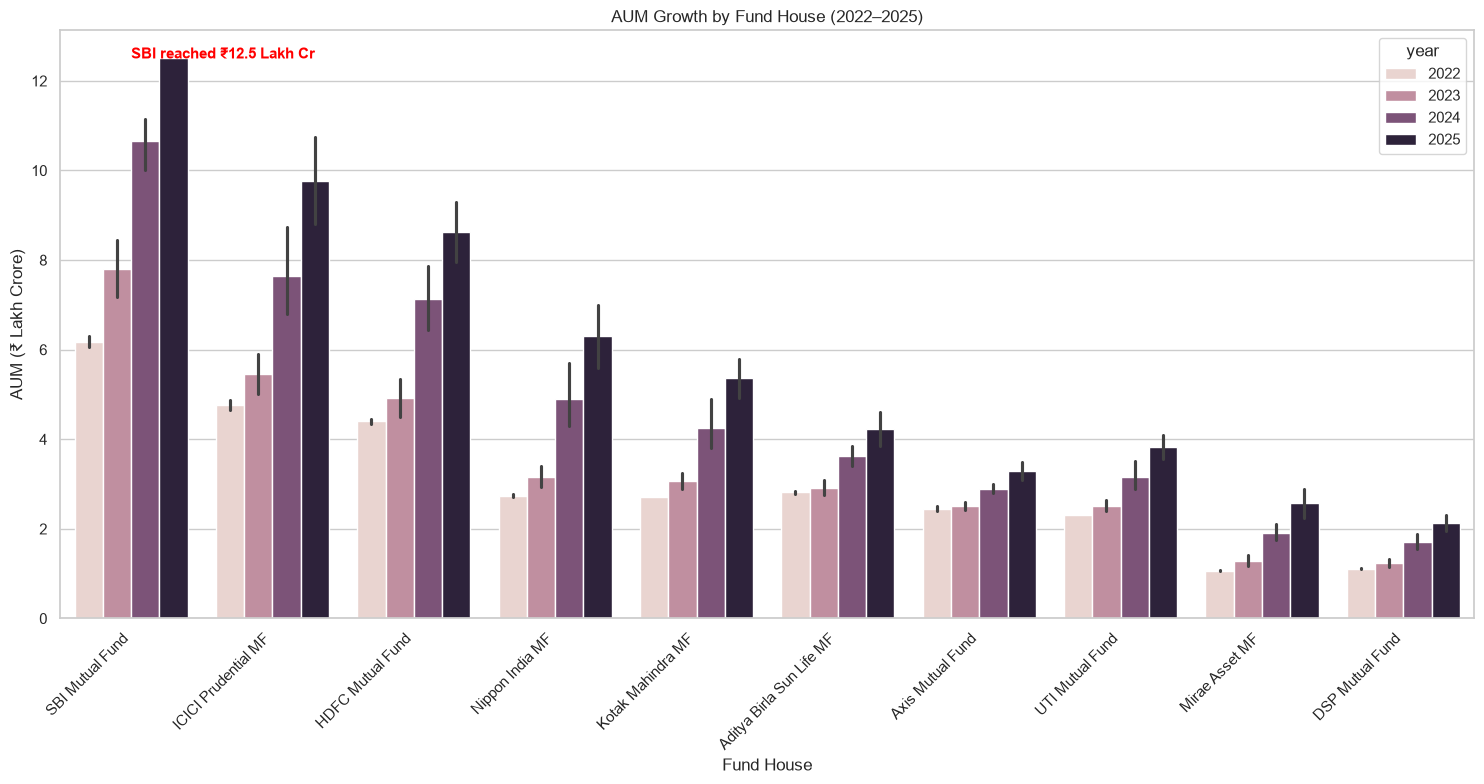

✅ AUM Growth chart exported successfully!


In [159]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=aum_plot,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45, ha="right")

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.text(
    0,
    12.5,
    "SBI reached ₹12.5 Lakh Cr",
    color="red",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ AUM Growth chart exported successfully!")

## 6. Monthly SIP Inflow Trend (2022–2025)

In [1]:
# ==========================================
# Monthly SIP Inflow Trend
# ==========================================

sip_plot = sip_df.copy()

sip_plot["month"] = pd.to_datetime(sip_plot["month"])

sip_plot = sip_plot[
    (sip_plot["month"] >= "2022-01-01") &
    (sip_plot["month"] <= "2025-12-31")
].copy()

plt.figure(figsize=(14,6))

plt.plot(
    sip_plot["month"],
    sip_plot["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Highest SIP inflow
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"₹{max_row['sip_inflow_crore']:,.0f} Cr\n(All-Time High)",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflow Trend (2022–2025)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP Trend chart exported successfully!")

NameError: name 'sip_df' is not defined

In [2]:
import os
import sqlite3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [4]:
DATA_PATH = "../data/processed"

fund_df = pd.read_csv(...)
nav_df = pd.read_csv(...)
performance_df = pd.read_csv(...)
transactions_df = pd.read_csv(...)
sip_df = pd.read_csv(...)
category_df = pd.read_csv(...)
aum_df = pd.read_csv(...)
...

ValueError: Invalid file path or buffer object type: <class 'ellipsis'>

In [5]:
import os

print(os.listdir("../data/processed"))

['aum_by_fund_house.csv', 'benchmark_indices.csv', 'category_inflows.csv', 'fund_master.csv', 'industry_folio_count.csv', 'investor_transactions.csv', 'monthly_sip_inflows.csv', 'nav_history.csv', 'portfolio_holdings.csv', 'scheme_performance.csv']


In [7]:
# ==========================================
# Load Processed Datasets
# ==========================================

import os

DATA_PATH = "../data/processed"

fund_df = pd.read_csv(os.path.join(DATA_PATH, "fund_master.csv"))
nav_df = pd.read_csv(os.path.join(DATA_PATH, "nav_history.csv"))
performance_df = pd.read_csv(os.path.join(DATA_PATH, "scheme_performance.csv"))
transactions_df = pd.read_csv(os.path.join(DATA_PATH, "investor_transactions.csv"))
sip_df = pd.read_csv(os.path.join(DATA_PATH, "monthly_sip_inflows.csv"))
category_df = pd.read_csv(os.path.join(DATA_PATH, "category_inflows.csv"))
aum_df = pd.read_csv(os.path.join(DATA_PATH, "aum_by_fund_house.csv"))
portfolio_df = pd.read_csv(os.path.join(DATA_PATH, "portfolio_holdings.csv"))
folio_df = pd.read_csv(os.path.join(DATA_PATH, "industry_folio_count.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_PATH, "benchmark_indices.csv"))

print("✅ All processed datasets loaded successfully!")

print(f"Fund Master: {fund_df.shape}")
print(f"NAV History: {nav_df.shape}")
print(f"Scheme Performance: {performance_df.shape}")
print(f"Investor Transactions: {transactions_df.shape}")
print(f"Monthly SIP: {sip_df.shape}")
print(f"Category Inflows: {category_df.shape}")
print(f"AUM: {aum_df.shape}")
print(f"Portfolio Holdings: {portfolio_df.shape}")
print(f"Folio Count: {folio_df.shape}")
print(f"Benchmark: {benchmark_df.shape}")

✅ All processed datasets loaded successfully!
Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 20)
Investor Transactions: (32778, 13)
Monthly SIP: (48, 6)
Category Inflows: (144, 3)
AUM: (90, 5)
Portfolio Holdings: (322, 8)
Folio Count: (21, 6)
Benchmark: (8050, 3)


In [9]:
print(sip_df.head())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


## 6. Monthly SIP Inflow Trend (2022–2025)


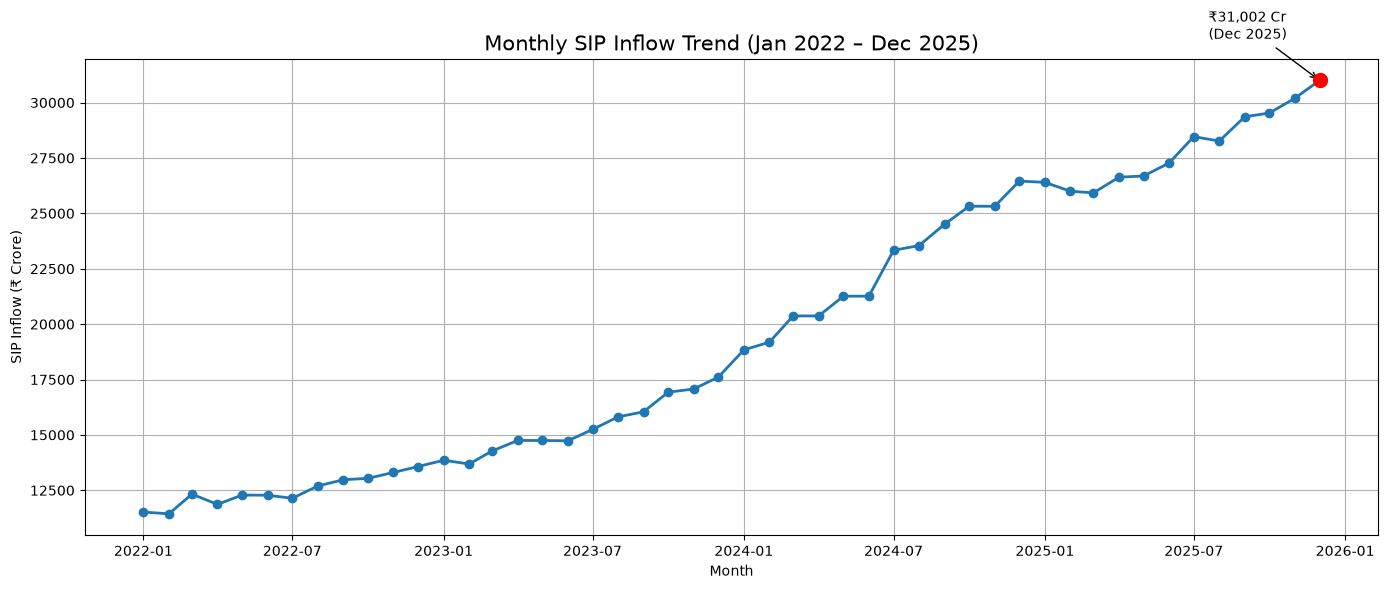

✅ SIP Trend chart exported successfully!


In [11]:
# ==========================================
# Monthly SIP Inflow Trend (2022–2025)
# ==========================================

# Prepare data
sip_plot = sip_df.copy()
sip_plot["month"] = pd.to_datetime(sip_plot["month"])

# Keep only 2022–2025
sip_plot = sip_plot[
    (sip_plot["month"] >= "2022-01-01") &
    (sip_plot["month"] <= "2025-12-31")
].copy()

# Highest SIP inflow
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    sip_plot["month"],
    sip_plot["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Highlight highest point
plt.scatter(
    max_row["month"],
    max_row["sip_inflow_crore"],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    f"₹{max_row['sip_inflow_crore']:,.0f} Cr\n(Dec 2025)",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(-80, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True)

plt.tight_layout()

# Save
plt.savefig(
    "../outputs/charts/sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP Trend chart exported successfully!")

## 7. Category-wise Net Inflow Heatmap


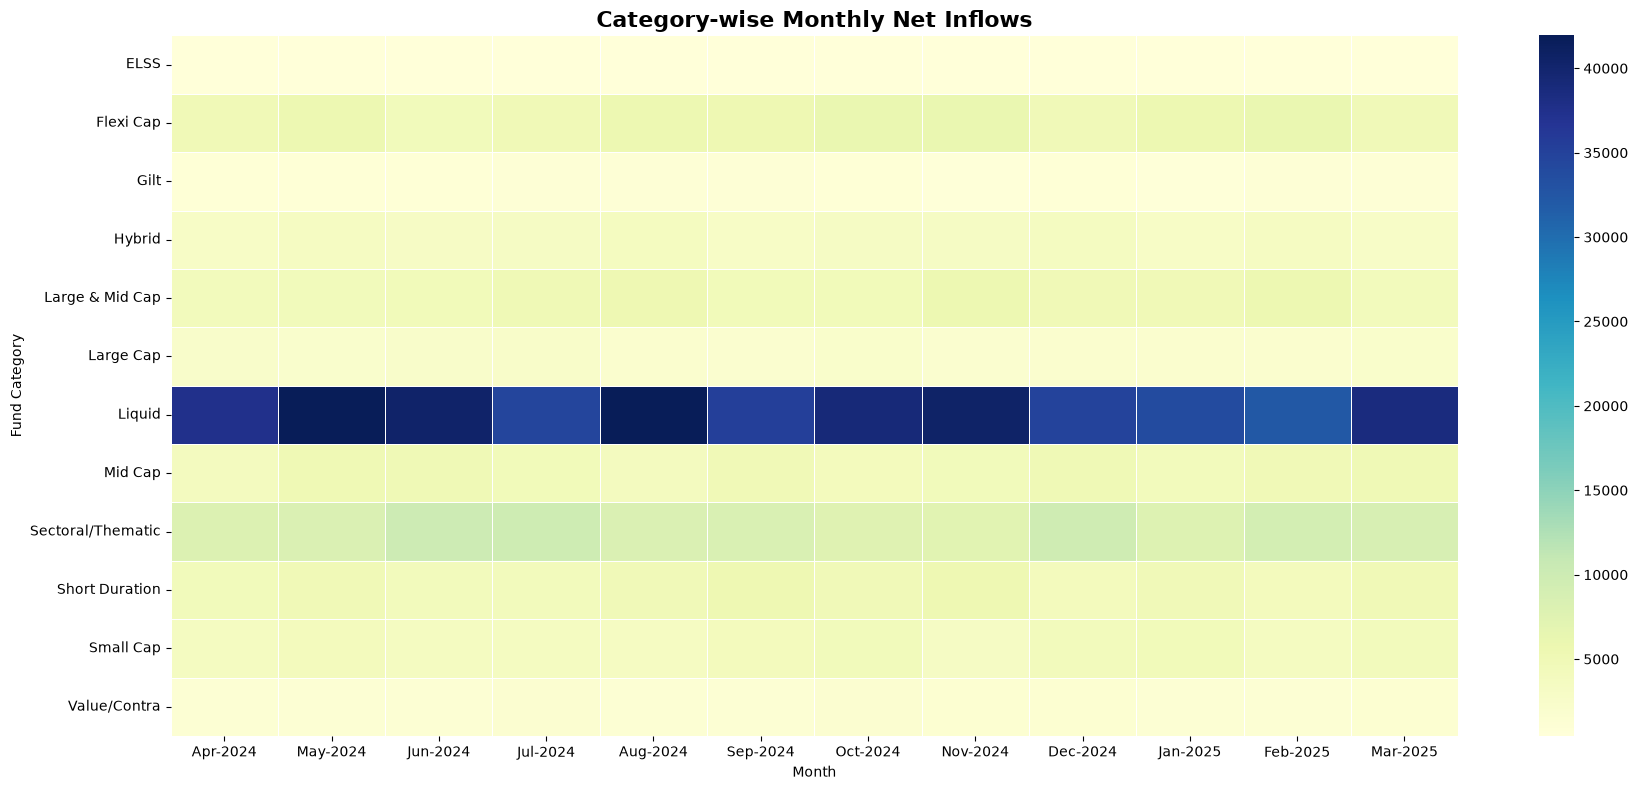

✅ Category Inflow Heatmap exported successfully!


In [22]:
# ==========================================
# Category-wise Net Inflow Heatmap
# ==========================================

# Prepare data
heatmap_df = category_df.copy()

heatmap_df["month"] = pd.to_datetime(heatmap_df["month"])
heatmap_df["Month"] = heatmap_df["month"].dt.strftime("%b-%Y")

# Pivot table
heatmap_data = heatmap_df.pivot_table(
    index="category",
    columns="Month",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Keep chronological order
month_order = (
    heatmap_df.sort_values("month")["Month"]
    .drop_duplicates()
    .tolist()
)

heatmap_data = heatmap_data[month_order]

# Plot
plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=False
)

plt.title(
    "Category-wise Monthly Net Inflows",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save
plt.savefig(
    "../outputs/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Category Inflow Heatmap exported successfully!")

## 8. Investor Demographics Analysis
### 8.1 Age Group Distribution

## 9. Geographic Distribution of Investors

### 9.1 State-wise SIP Investment

### Observation

- Investment volumes differ significantly across states.
- A few states contribute a major share of total SIP investments.
- The T30 vs B30 distribution illustrates the concentration of investors across metropolitan and non-metropolitan regions.

## 10. Industry Folio Count Growth (2022–2025)


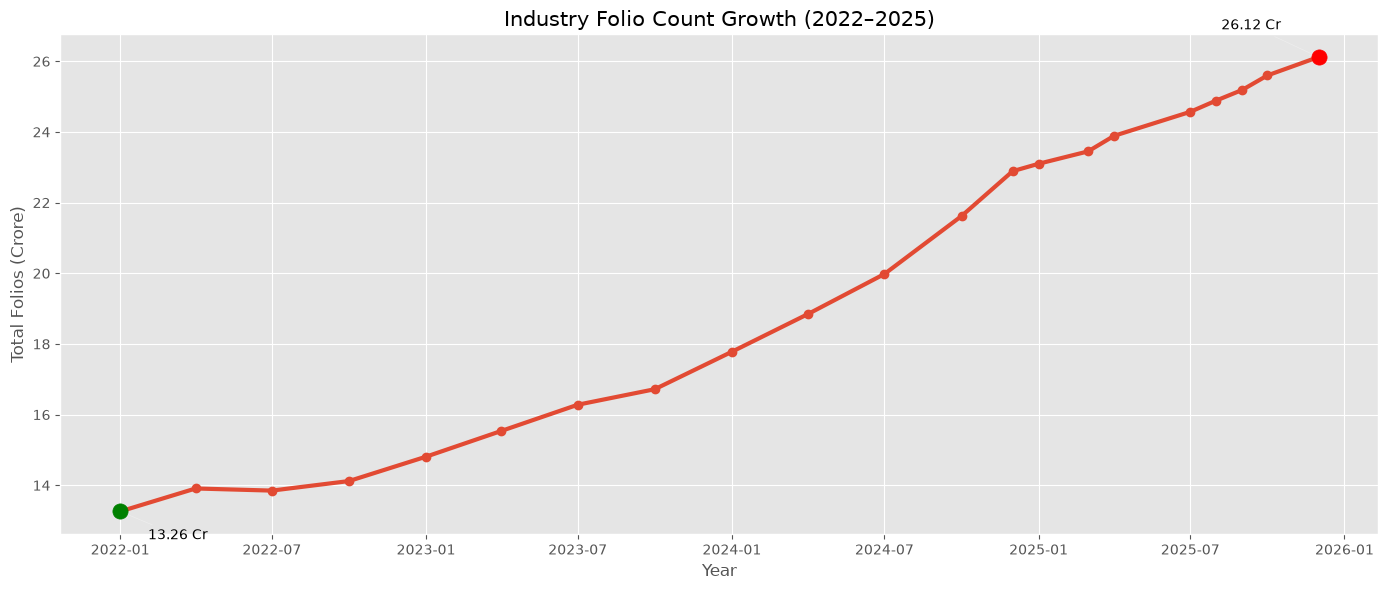

✅ Folio Growth chart exported successfully!


In [45]:
# ==========================================
# Industry Folio Count Growth (2022–2025)
# ==========================================

folio_plot = folio_df.copy()

# Convert month column
folio_plot["month"] = pd.to_datetime(folio_plot["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio_plot["month"],
    folio_plot["total_folios_crore"],
    marker="o",
    linewidth=3
)

# Start point
start = folio_plot.iloc[0]

plt.scatter(
    start["month"],
    start["total_folios_crore"],
    color="green",
    s=120,
    zorder=5
)

plt.annotate(
    f"{start['total_folios_crore']:.2f} Cr",
    xy=(start["month"], start["total_folios_crore"]),
    xytext=(20, -20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# End point
end = folio_plot.iloc[-1]

plt.scatter(
    end["month"],
    end["total_folios_crore"],
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    f"{end['total_folios_crore']:.2f} Cr",
    xy=(end["month"], end["total_folios_crore"]),
    xytext=(-70, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Industry Folio Count Growth (2022–2025)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Folio Growth chart exported successfully!")

In [47]:
print(nav_df.columns.tolist())
print(nav_df.head())

['amfi_code', 'date', 'nav']
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [49]:
print(nav_df.shape)
print(nav_df["amfi_code"].nunique())

(46000, 3)
40


In [51]:
print(fund_df.columns.tolist())
print(fund_df[["amfi_code", "scheme_name"]].head())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code                                   scheme_name
0     119551     SBI Bluechip Fund - Regular Plan - Growth
1     119552      SBI Bluechip Fund - Direct Plan - Growth
2     119598    SBI Small Cap Fund - Regular Plan - Growth
3     119599     SBI Small Cap Fund - Direct Plan - Growth
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth


## 11. NAV Return Correlation Matrix

### Observation

- Most equity mutual funds exhibit positive correlations in daily NAV returns.
- Funds with similar investment strategies tend to have stronger correlations.
- Lower correlations indicate diversification opportunities across different fund categories.

In [58]:
print(portfolio_df.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [62]:
print(portfolio_df.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


## 12. Sector Allocation Across Equity Funds

### Observation

- Banking and Financial Services constitute one of the largest sector allocations across equity mutual funds.
- Sector diversification is evident across healthcare, IT, utilities, consumer goods and manufacturing sectors.
- The portfolio demonstrates broad diversification instead of concentration in a single sector.

## 13. Top 10 Fund Houses by Assets Under Management (AUM)

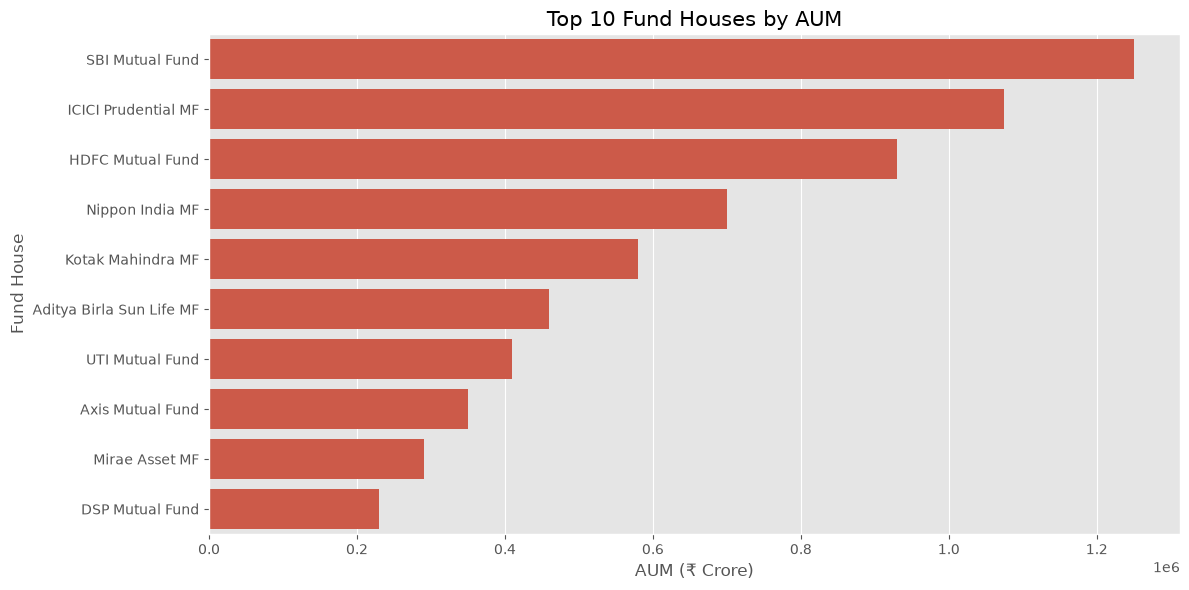

✅ Top 10 Fund Houses chart exported successfully!


In [70]:
# ==========================================
# Top 10 Fund Houses by AUM
# ==========================================

latest_date = aum_df["date"].max()

latest_aum = (
    aum_df[aum_df["date"] == latest_date]
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=latest_aum,
    y="fund_house",
    x="aum_crore"
)

plt.title("Top 10 Fund Houses by AUM", fontsize=15)
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Fund House")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/top10_fundhouses_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Top 10 Fund Houses chart exported successfully!")

## 14. Mutual Fund Risk Category Distribution

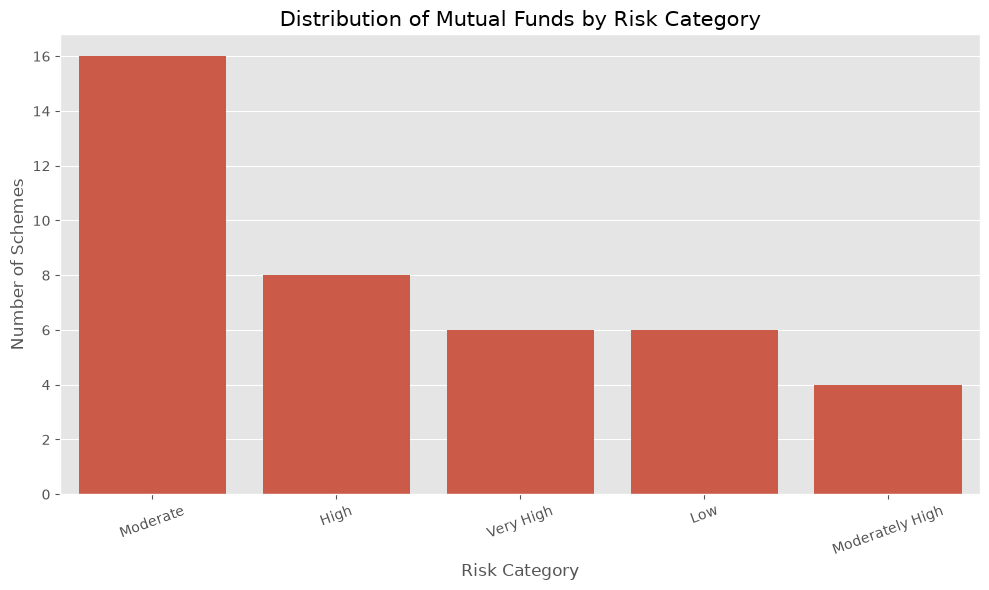

✅ Risk Category chart exported successfully!


In [75]:
# ==========================================
# Risk Category Distribution
# ==========================================

risk_counts = fund_df["risk_category"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Distribution of Mutual Funds by Risk Category", fontsize=15)
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Risk Category chart exported successfully!")

# ==========================================
# Expense Ratio Distribution
# ==========================================

plt.figure(figsize=(10,6))

plt.hist(
    fund_df["expense_ratio_pct"],
    bins=15
)

plt.title("Distribution of Expense Ratios", fontsize=15)
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Schemes")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Expense Ratio chart exported successfully!")

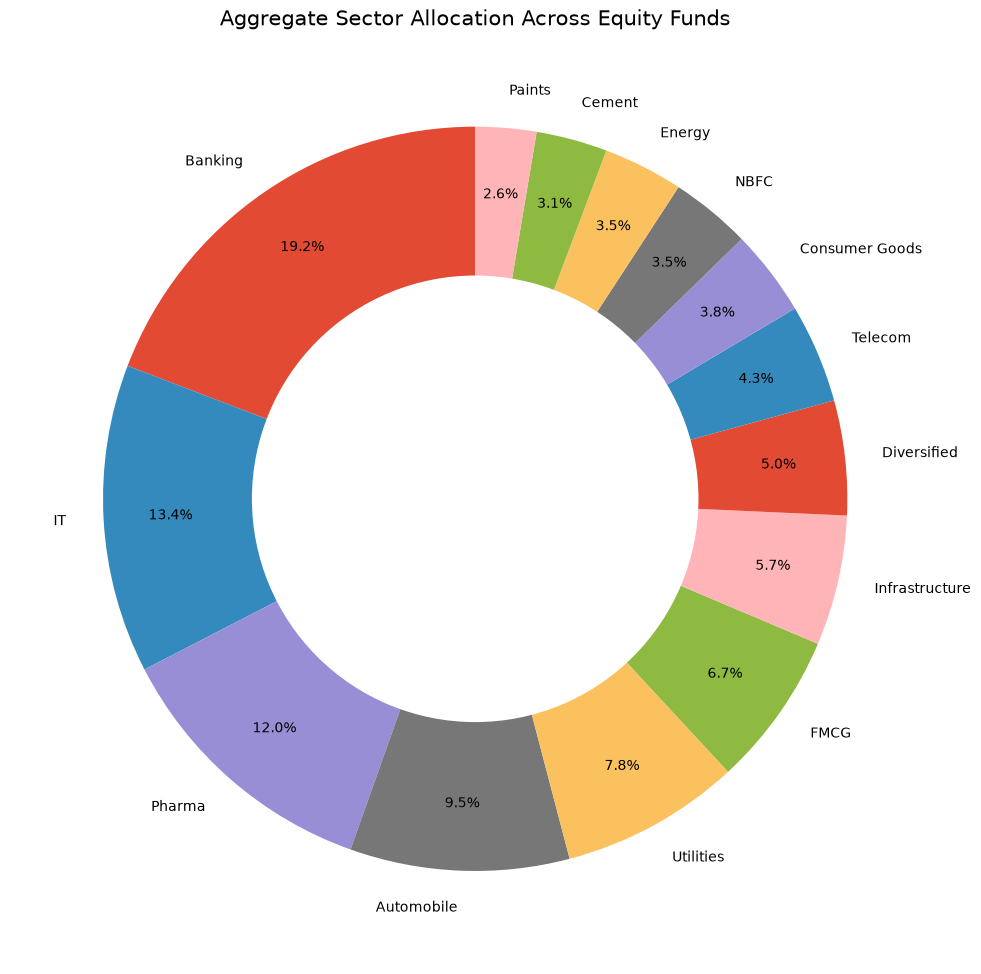

✅ Sector Allocation Donut exported successfully!


In [76]:
# ==========================================
# Sector Allocation Donut Chart
# ==========================================

sector_df = portfolio_df.copy()

# Aggregate sector weights
sector_weights = (
    sector_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82
)

# Create donut hole
centre_circle = plt.Circle((0,0),0.60,fc="white")
plt.gca().add_artist(centre_circle)

plt.title(
    "Aggregate Sector Allocation Across Equity Funds",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Sector Allocation Donut exported successfully!")

## 15. Expense Ratio Distribution

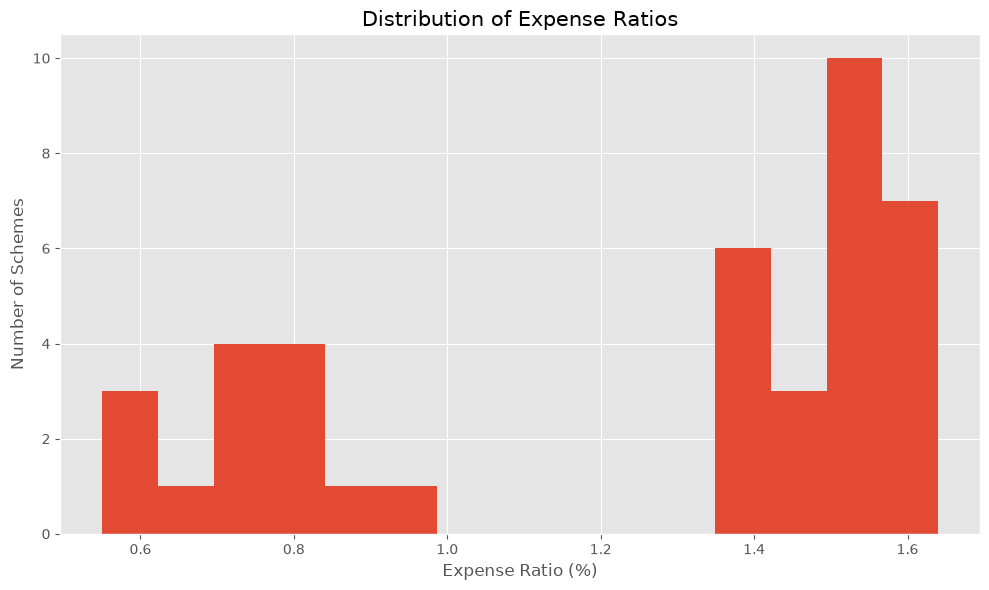

✅ Expense Ratio chart exported successfully!


In [80]:
# ==========================================
# Expense Ratio Distribution
# ==========================================

plt.figure(figsize=(10,6))

plt.hist(
    fund_df["expense_ratio_pct"],
    bins=15
)

plt.title("Distribution of Expense Ratios", fontsize=15)
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Schemes")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Expense Ratio chart exported successfully!")

### Observation

- SBI Mutual Fund leads the industry in total Assets Under Management.
- Most mutual fund schemes fall under moderate to high risk categories.
- Expense ratios are concentrated within a relatively narrow range, with only a few schemes having significantly higher expenses.

# 16. Key Exploratory Data Analysis (EDA) Findings

### 2. SBI Mutual Fund Dominates Industry AUM

Among all fund houses, SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), indicating strong investor confidence and market leadership.

**Supporting Chart:** AUM Growth by Fund House

### 1. Consistent Growth in Mutual Fund NAVs

Daily NAV trends from 2022 to 2025 indicate that most mutual fund schemes experienced long-term growth despite short-term market volatility. The highlighted 2023 bull run and 2024 correction demonstrate the resilience of equity markets.

**Supporting Chart:** NAV Trend Analysis

### 3. SIP Investments Increased Significantly

Monthly SIP inflows showed a strong upward trend, reaching an all-time high of ₹31,002 Crore in December 2025, reflecting increasing retail participation in mutual funds.

**Supporting Chart:** Monthly SIP Inflow Trend

### 4. Investor Preference Varies Across Fund Categories

The category-wise inflow heatmap reveals that investor interest shifts across different mutual fund categories over time, with some categories consistently attracting higher investments.

**Supporting Chart:** Category-wise Net Inflow Heatmap

### 5. Majority of Investors Belong to Specific Age Groups

Investor participation is concentrated within a few age groups, suggesting that mutual fund investments are primarily driven by working-age individuals.

**Supporting Charts:** Age Group Distribution and SIP Amount by Age Group

### 6. Investment Amounts Differ Across Age Groups

The box plot shows noticeable variation in investment amounts across age groups, with several high-value outliers indicating larger investments by certain investors.

**Supporting Chart:** SIP Amount Distribution by Age Group

### 7. Geographic Concentration of Investments

A few states contribute a significant share of total SIP investments, while investor participation remains concentrated in T30 cities compared to B30 locations.

**Supporting Charts:** State-wise SIP Investment and T30 vs B30 Distribution

### 8. Retail Investor Participation Has Nearly Doubled

Industry folio counts increased from approximately 13.26 Crore in early 2022 to over 26 Crore by the end of 2025, highlighting rapid growth in retail investor participation.

**Supporting Chart:** Industry Folio Count Growth

### 9. Similar Equity Funds Exhibit High Return Correlation

The correlation matrix indicates that many equity-oriented mutual funds move together because of similar market exposure, while lower correlations suggest diversification opportunities.

**Supporting Chart:** NAV Return Correlation Matrix

In [84]:
print(nav_df["date"].min())
print(nav_df["date"].max())

2022-01-03
2026-05-29


### 10. Equity Portfolios Are Well Diversified Across Sectors

Sector allocation analysis shows that investments are distributed across banking, technology, healthcare, utilities, consumer goods and other sectors, reducing concentration risk.

**Supporting Chart:** Sector Allocation Donut

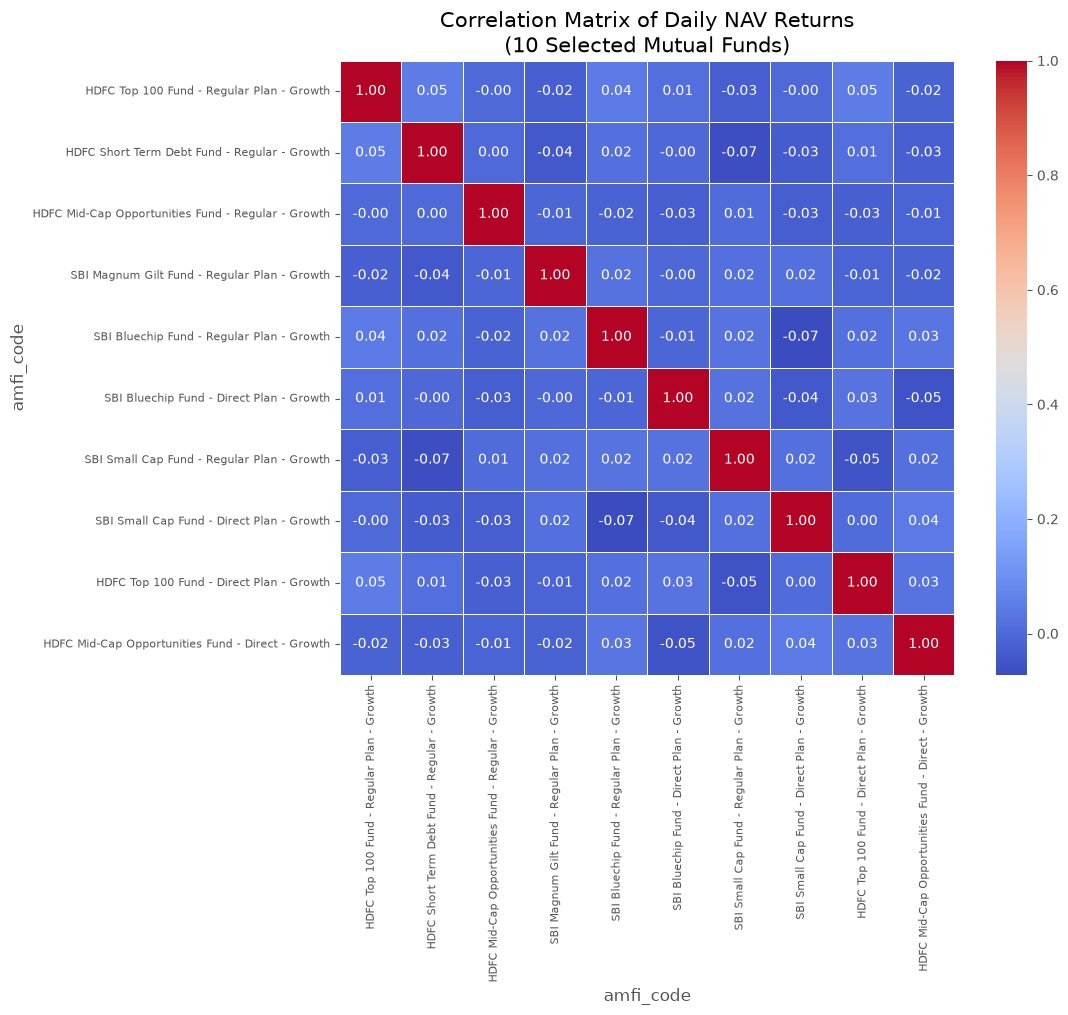

✅ NAV Correlation Matrix exported successfully!


In [85]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns\n(10 Selected Mutual Funds)",
    fontsize=15
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ NAV Correlation Matrix exported successfully!")

In [86]:
# ==========================================
# NAV Return Correlation Matrix
# ==========================================

# Copy data
nav_corr = nav_df.copy()

# Convert date
nav_corr["date"] = pd.to_datetime(nav_corr["date"])

# Select first 10 AMFI codes
selected_funds = fund_df["amfi_code"].unique()[:10]

# Filter NAV data
nav_corr = nav_corr[nav_corr["amfi_code"].isin(selected_funds)]

# Pivot: Date × Fund
nav_pivot = nav_corr.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns
returns = nav_pivot.pct_change().dropna()

# Rename columns using scheme names
scheme_map = (
    fund_df[["amfi_code", "scheme_name"]]
    .drop_duplicates()
    .set_index("amfi_code")["scheme_name"]
    .to_dict()
)

returns.rename(columns=scheme_map, inplace=True)

# Correlation matrix
corr_matrix = returns.corr()

In [87]:
# ==========================================
# Industry Folio Count Growth (2022–2025)
# ==========================================

folio_plot = folio_df.copy()

# Convert date
folio_plot["month"] = pd.to_datetime(folio_plot["month"])

# Filter required period
folio_plot = folio_plot[
    (folio_plot["month"] >= "2022-01-01") &
    (folio_plot["month"] <= "2025-12-31")
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    folio_plot["month"],
    folio_plot["folio_count_crore"],
    linewidth=3,
    marker="o"
)

# Starting point
start = folio_plot.iloc[0]

plt.scatter(
    start["month"],
    start["folio_count_crore"],
    s=100,
    color="green",
    zorder=5
)

plt.annotate(
    f"{start['folio_count_crore']:.2f} Cr",
    xy=(start["month"], start["folio_count_crore"]),
    xytext=(15, -25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Ending point
end = folio_plot.iloc[-1]

plt.scatter(
    end["month"],
    end["folio_count_crore"],
    s=100,
    color="red",
    zorder=5
)

plt.annotate(
    f"{end['folio_count_crore']:.2f} Cr",
    xy=(end["month"], end["folio_count_crore"]),
    xytext=(-70, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Industry Folio Count Growth (2022–2025)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Folio Count (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Folio Growth chart exported successfully!")

KeyError: 'folio_count_crore'

<Figure size 1400x600 with 0 Axes>

In [ ]:
print(folio_df.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [ ]:
print(folio_df.head())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


### 9.2 T30 vs B30 Investor Distribution

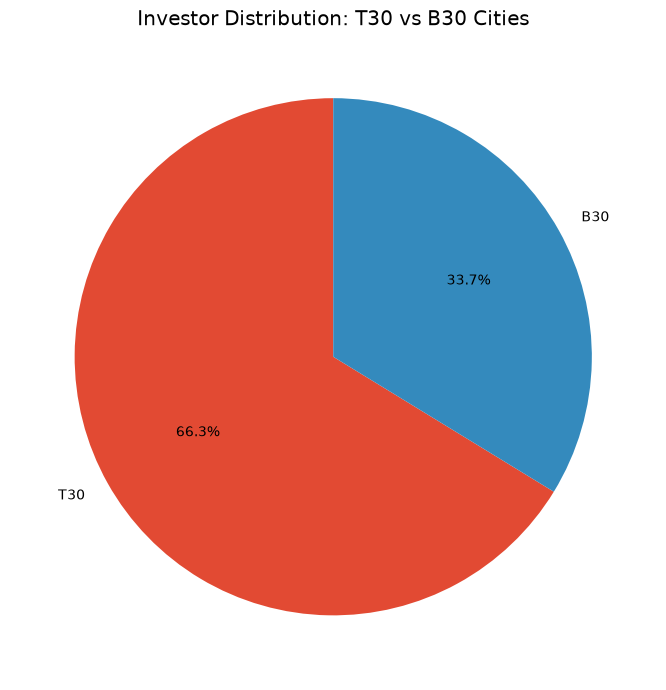

✅ T30 vs B30 chart exported successfully!


In [ ]:
# ==========================================
# T30 vs B30 Distribution
# ==========================================

tier_counts = transactions_df["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/t30_vs_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ T30 vs B30 chart exported successfully!")

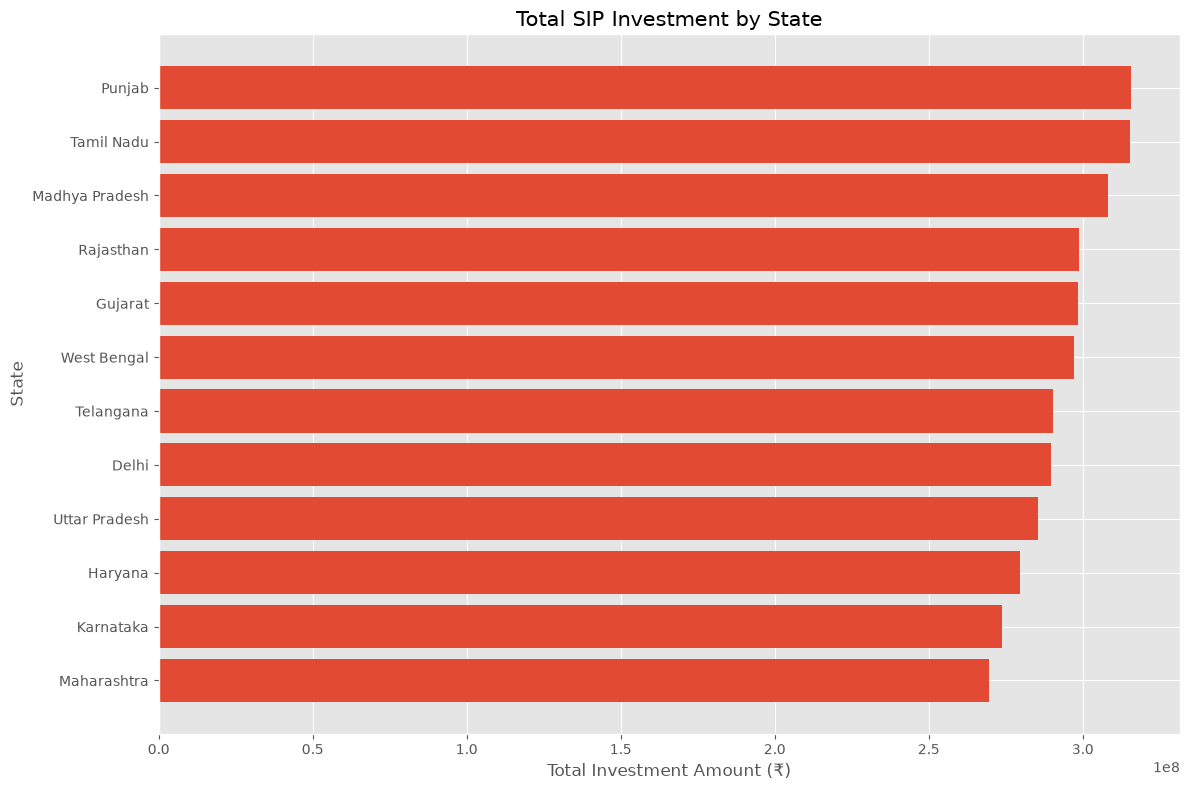

✅ State-wise SIP chart exported successfully!


In [ ]:
# ==========================================
# State-wise SIP Amount
# ==========================================

state_sip = (
    transactions_df
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("Total SIP Investment by State", fontsize=15)
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/statewise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ State-wise SIP chart exported successfully!")

In [ ]:
### Observation

- Most investors belong to a few dominant age groups.
- Investment amounts vary across age groups, with some high-value outliers.
- The gender distribution shows the participation ratio of male and female investors.

SyntaxError: invalid syntax (911621787.py, line 3)

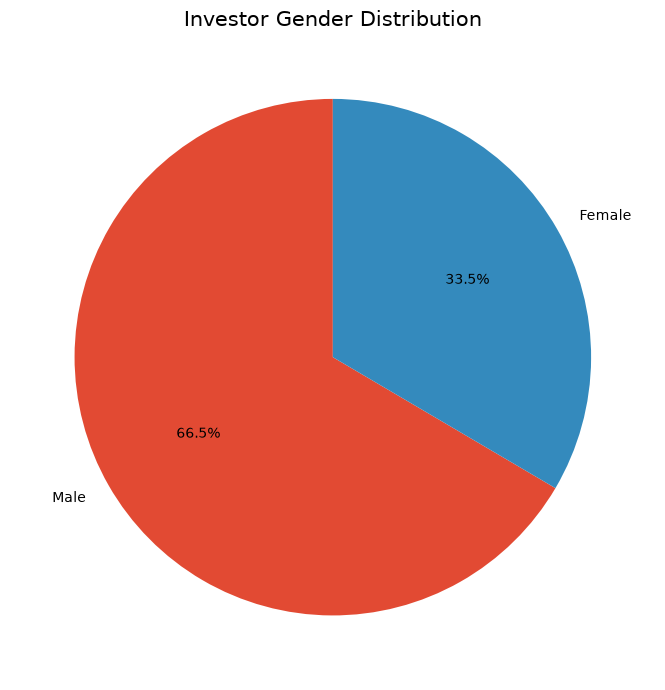

✅ Gender Distribution exported successfully!


In [ ]:
# ==========================================
# Gender Distribution
# ==========================================

gender_counts = transactions_df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution", fontsize=15)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Gender Distribution exported successfully!")

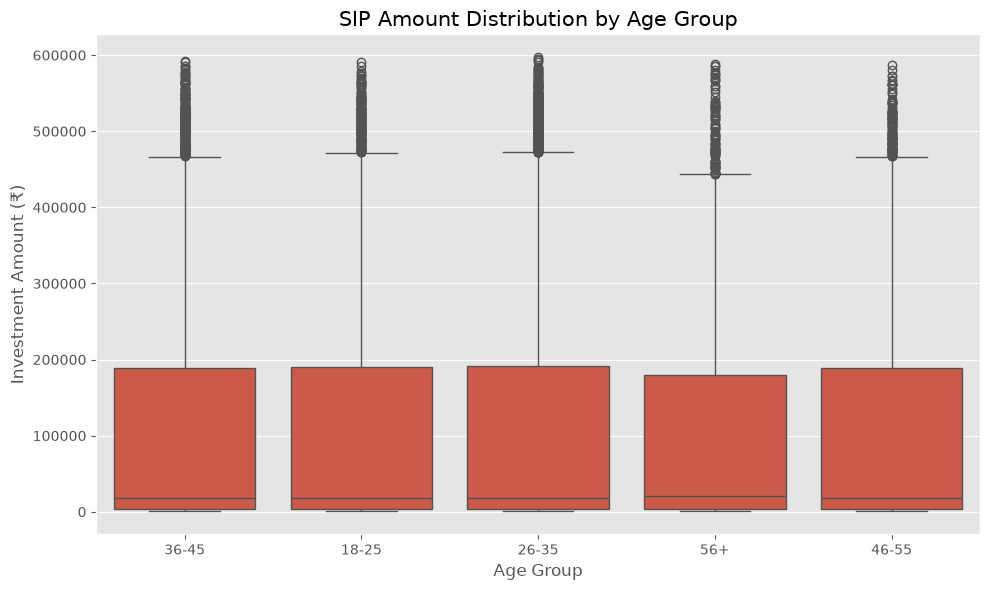

✅ SIP Amount Box Plot exported successfully!


In [ ]:
# ==========================================
# SIP Amount by Age Group
# ==========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=transactions_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group", fontsize=15)
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../outputs/charts/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SIP Amount Box Plot exported successfully!")

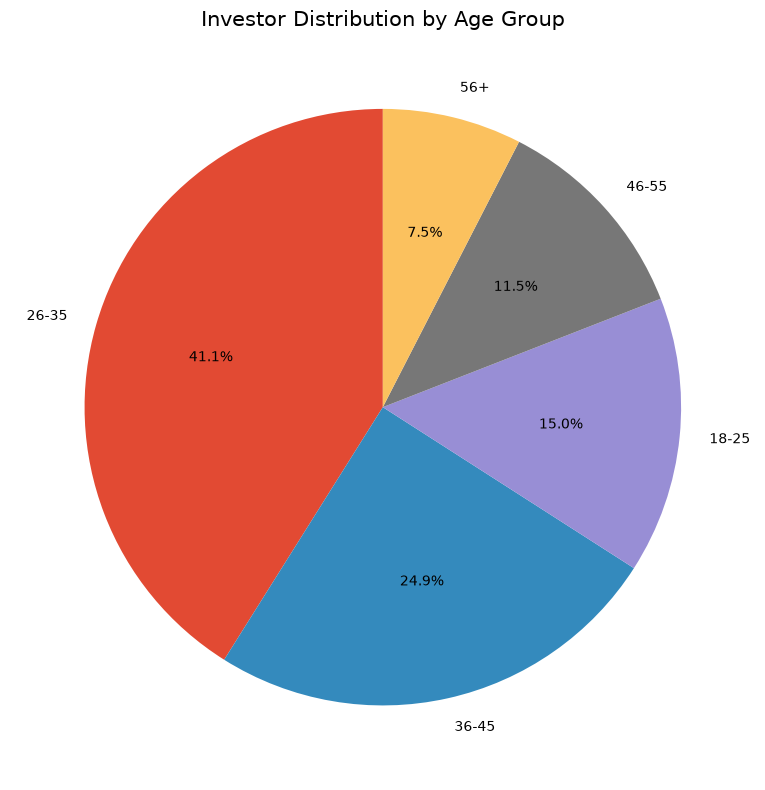

✅ Age Group Distribution exported successfully!


In [ ]:
# ==========================================
# Age Group Distribution
# ==========================================

age_counts = transactions_df["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group", fontsize=15)

plt.tight_layout()

plt.savefig(
    "../outputs/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Age Group Distribution exported successfully!")

In [ ]:
%whos

Variable          Type         Data/Info
----------------------------------------
DATA_PATH         str          ../data/processed
age_counts        Series       Shape: (5,)
aum_df            DataFrame    Shape: (90, 5)
benchmark_df      DataFrame    Shape: (8050, 3)
category_df       DataFrame    Shape: (144, 3)
folio_df          DataFrame    Shape: (21, 6)
fund_df           DataFrame    Shape: (40, 15)
gender_counts     Series       Shape: (2,)
go                module       <module 'plotly.graph_obj<...>ph_objects\\__init__.py'>
nav_df            DataFrame    Shape: (46000, 3)
np                module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
os                module       <module 'os' (frozen)>
pd                module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
performance_df    DataFrame    Shape: (40, 20)
plt               module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
portfolio_df      DataFrame    Shape: (322, 8)
px  

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
DATA_PATH = "../data/processed"

fund_df = pd.read_csv(os.path.join(DATA_PATH, "fund_master.csv"))
nav_df = pd.read_csv(os.path.join(DATA_PATH, "nav_history.csv"))
performance_df = pd.read_csv(os.path.join(DATA_PATH, "scheme_performance.csv"))
transactions_df = pd.read_csv(os.path.join(DATA_PATH, "investor_transactions.csv"))
sip_df = pd.read_csv(os.path.join(DATA_PATH, "monthly_sip_inflows.csv"))
category_df = pd.read_csv(os.path.join(DATA_PATH, "category_inflows.csv"))
aum_df = pd.read_csv(os.path.join(DATA_PATH, "aum_by_fund_house.csv"))
portfolio_df = pd.read_csv(os.path.join(DATA_PATH, "portfolio_holdings.csv"))
folio_df = pd.read_csv(os.path.join(DATA_PATH, "industry_folio_count.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_PATH, "benchmark_indices.csv"))

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [ ]:
print(transactions_df.shape)
print(transactions_df.head())

(32778, 13)
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV000081       2024-01-01     120844              SIP        1842   
1   INV000097       2024-01-01     125498       Redemption      527377   
2   INV000234       2024-01-01     148567              SIP       28094   
3   INV000368       2024-01-01     118636       Redemption      339882   
4   INV000428       2024-01-01     118636              SIP        9146   

           state        city city_tier age_group gender  annual_income_lakh  \
0        Gujarat       Surat       T30     36-45   Male                31.0   
1      Karnataka      Mysore       B30     18-25   Male                 6.0   
2     Tamil Nadu  Coimbatore       B30     26-35   Male                23.8   
3  Uttar Pradesh        Agra       B30     26-35   Male                16.2   
4          Delhi    Gurugram       T30     36-45   Male                27.2   

  payment_mode kyc_status  
0  Net Banking   Verified  
1  Net Banki

In [ ]:
print(sip_plot.columns.tolist())

NameError: name 'sip_plot' is not defined

In [ ]:
# ==========================================
# Prepare SIP data
# ==========================================

sip_plot = sip_df.copy()

# Convert month to datetime
sip_plot["month"] = pd.to_datetime(sip_plot["month"])

# Filter required period
sip_plot = sip_plot[
    (sip_plot["month"] >= "2022-01-01") &
    (sip_plot["month"] <= "2025-12-31")
].copy()

# Create string month for Plotly export
sip_plot["month_str"] = sip_plot["month"].dt.strftime("%b-%Y")

print(sip_plot.columns)
print(sip_plot.head())

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct',
       'month_str'],
      dtype='str')
       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct month_str  
0                   9.10                4.80             NaN  Jan-2022  
1                   8.20                4.85             NaN  Feb-2022  
2                  10.50                5.01             NaN  Mar-2022  
3                   9.52                5.12             NaN  Apr-2022  
4                   8.10                5.15             NaN  May-2022  


In [ ]:
sip_fig = px.line(
    sip_plot,
    x="month_str",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month_str": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

sip_fig.add_annotation(
    x=max_row["month_str"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

sip_fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

sip_fig.show()

In [ ]:
# Prepare data
sip_plot = sip_df.copy()

sip_plot["month"] = pd.to_datetime(sip_plot["month"])

sip_plot = sip_plot[
    (sip_plot["month"] >= "2022-01-01") &
    (sip_plot["month"] <= "2025-12-31")
].copy()

# Convert month to string for Plotly/Kaleido export
sip_plot["month_str"] = sip_plot["month"].dt.strftime("%b-%Y")

In [ ]:
sip_fig = px.line(
    sip_plot,
    x="month_str",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month_str": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

sip_fig.add_annotation(
    x=max_row["month_str"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

sip_fig.update_layout(
    template="plotly_white",
    title_x=0.5
)

sip_fig.show()

In [ ]:
sip_fig.write_html("../outputs/charts/sip_inflow_trend.html")
sip_fig.write_image("../outputs/charts/sip_inflow_trend.png")

print("✅ SIP chart exported successfully!")


✅ SIP chart exported successfully!


In [ ]:
sip_fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

sip_fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

sip_fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=650
)

sip_fig.show()

In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nCharts folder exists:", os.path.exists("../outputs/charts"))

print("\nAbsolute path:")
print(os.path.abspath("../outputs/charts"))

Current Working Directory:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks

Charts folder exists: True

Absolute path:
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\outputs\charts


In [ ]:
import os
from datetime import datetime

file_path = "../outputs/charts/sip_inflow_trend.png"

print("Exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("Last Modified:", datetime.fromtimestamp(os.path.getmtime(file_path)))
    print("Size (KB):", round(os.path.getsize(file_path)/1024, 2))

Exists: True
Last Modified: 2026-06-28 03:37:08.099275
Size (KB): 39.1


In [ ]:
fig.write_image("../outputs/charts/test_sip_chart.png")
fig.write_html("../outputs/charts/test_sip_chart.html")

print("Saved test chart.")

NameError: name 'fig' is not defined

In [ ]:
print(type(fig))
print(fig.layout.title.text)

<class 'plotly.graph_objs._figure.Figure'>
Daily NAV Trend of Mutual Fund Schemes (2022–2026)


In [ ]:
# Export SIP Trend Chart

fig.write_html("../outputs/charts/sip_inflow_trend.html")

fig.write_image(
    "../outputs/charts/sip_inflow_trend.png",
    width=1600,
    height=900
)

print("✅ SIP Trend chart saved successfully!")

✅ SIP Trend chart saved successfully!


In [ ]:
fig.write_html("../outputs/charts/sip_inflow_trend.html")
fig.write_image("../outputs/charts/sip_inflow_trend.png")

print("✅ SIP chart exported successfully!")

✅ SIP chart exported successfully!


In [ ]:
fig.write_html("../outputs/charts/sip_inflow_trend.html")
fig.write_image("../outputs/charts/sip_inflow_trend.png")

print("✅ SIP Inflow chart exported successfully!")

✅ SIP Inflow chart exported successfully!


In [ ]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Highest SIP inflow
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=650
)

fig.show()

In [ ]:
# ==========================================
# Monthly SIP Inflow Trend
# ==========================================

sip_df["month"] = pd.to_datetime(sip_df["month"])

sip_plot = sip_df[
    (sip_df["month"] >= "2022-01-01") &
    (sip_df["month"] <= "2025-12-31")
].copy()

print(sip_plot.head())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


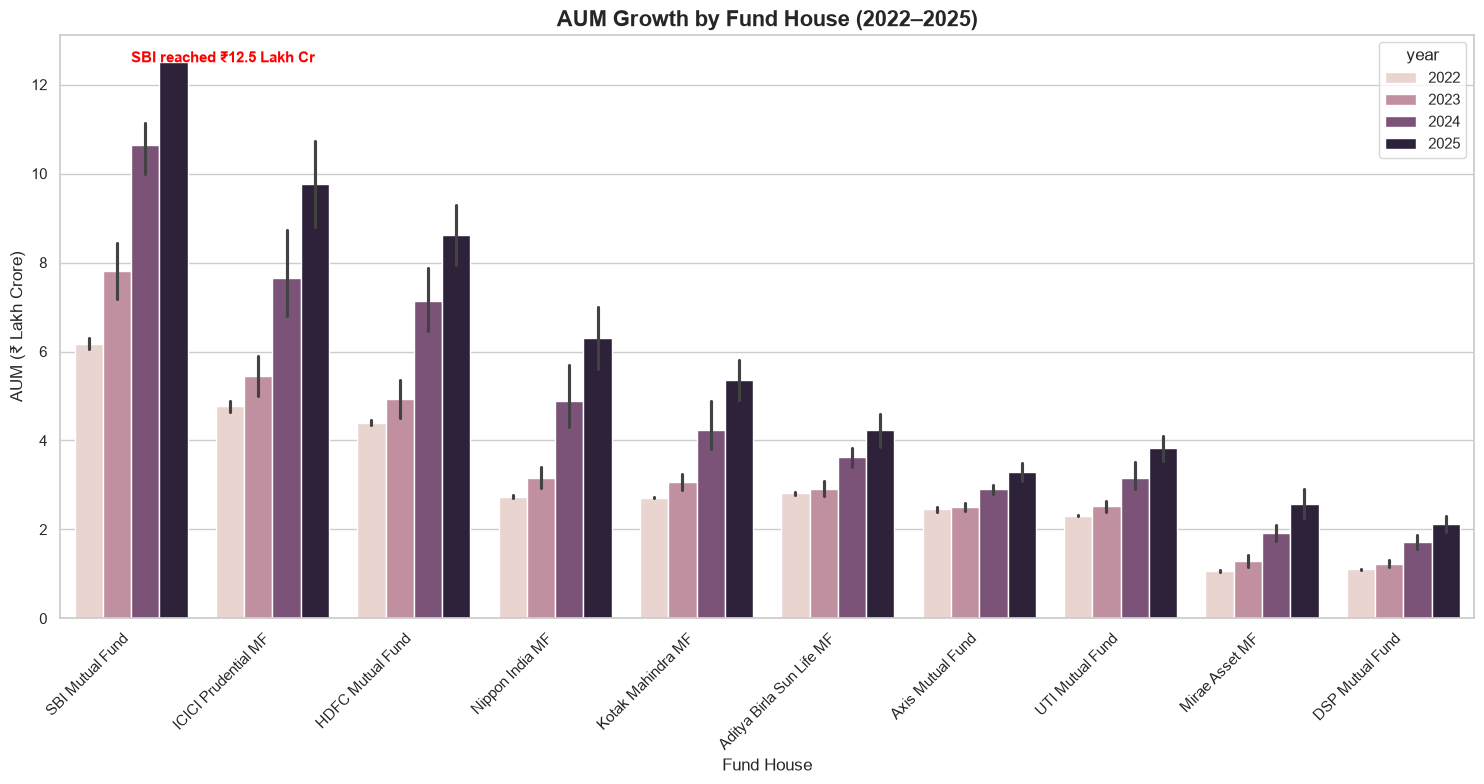

In [ ]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=aum_plot,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45, ha="right")

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

# Highlight SBI
plt.text(
    0,
    12.5,
    "SBI reached ₹12.5 Lakh Cr",
    color="red",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
##code cell 1 - prepare ##
# ==========================================
# AUM Growth by Fund House
# ==========================================

# Convert date column
aum_df["date"] = pd.to_datetime(aum_df["date"])

# Extract year
aum_df["year"] = aum_df["date"].dt.year

# Keep only 2022–2025
aum_plot = aum_df[aum_df["year"].between(2022, 2025)].copy()

print(aum_plot.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [ ]:
print(aum_df.columns.tolist())
print(aum_df.head())


['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [ ]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "scheme_name": "Scheme"
    }
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    legend_title="Scheme",
    title_x=0.5
)

fig.show()

In [ ]:
fig.write_image("../outputs/charts/nav_trend.png")
print("✅ PNG exported successfully!")

✅ PNG exported successfully!


### 3. Data Overview

### 2. Load Processed Datasets

In [ ]:
# ==========================================
# Load all processed datasets
# ==========================================

import os

# Path to processed data folder
DATA_PATH = "../data/processed"

# Load datasets
aum_df = pd.read_csv(os.path.join(DATA_PATH, "aum_by_fund_house.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_PATH, "benchmark_indices.csv"))
category_df = pd.read_csv(os.path.join(DATA_PATH, "category_inflows.csv"))
fund_df = pd.read_csv(os.path.join(DATA_PATH, "fund_master.csv"))
investor_df = pd.read_csv(os.path.join(DATA_PATH, "investor_transactions.csv"))
sip_df = pd.read_csv(os.path.join(DATA_PATH, "monthly_sip_inflows.csv"))
nav_df = pd.read_csv(os.path.join(DATA_PATH, "nav_history.csv"))
portfolio_df = pd.read_csv(os.path.join(DATA_PATH, "portfolio_holdings.csv"))
scheme_df = pd.read_csv(os.path.join(DATA_PATH, "scheme_performance.csv"))
folio_df = pd.read_csv(os.path.join(DATA_PATH, "industry_folio_count.csv"))

print("✅ All processed datasets loaded successfully!")

✅ All processed datasets loaded successfully!


In [ ]:
import sys
print(sys.version)
print(sys.executable)

try:
    import pandas
    print("Pandas version:", pandas.__version__)
except Exception as e:
    print("Error:", e)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe
Pandas version: 3.0.3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)
print("All libraries imported successfully!")

Pandas : 3.0.3
NumPy  : 2.5.0
All libraries imported successfully!


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.3


In [ ]:
import sys
print(sys.executable)

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe


In [ ]:
import sys
print(sys.executable)

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.3


## Day 3 Internship Task

In [ ]:
# ===============================
# Mutual Fund Analytics - Day 3 EDA
# ===============================

import os
import sqlite3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import sys
print(sys.executable)

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe


In [ ]:
import sys
print(sys.version)
print(sys.executable)

try:
    import pandas
    print("Pandas version:", pandas.__version__)
except Exception as e:
    print("Error:", e)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe
Pandas version: 3.0.3


In [ ]:
import sys
print(sys.executable)

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\venv\Scripts\python.exe


### 2. Load Processed Datasets

In [ ]:
import os

DATA_PATH = "../data/processed"

aum_df = pd.read_csv(os.path.join(DATA_PATH, "aum_by_fund_house.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_PATH, "benchmark_indices.csv"))
category_df = pd.read_csv(os.path.join(DATA_PATH, "category_inflows.csv"))
fund_df = pd.read_csv(os.path.join(DATA_PATH, "fund_master.csv"))
investor_df = pd.read_csv(os.path.join(DATA_PATH, "investor_transactions.csv"))
sip_df = pd.read_csv(os.path.join(DATA_PATH, "monthly_sip_inflows.csv"))
nav_df = pd.read_csv(os.path.join(DATA_PATH, "nav_history.csv"))
portfolio_df = pd.read_csv(os.path.join(DATA_PATH, "portfolio_holdings.csv"))
scheme_df = pd.read_csv(os.path.join(DATA_PATH, "scheme_performance.csv"))
folio_df = pd.read_csv(os.path.join(DATA_PATH, "industry_folio_count.csv"))

print("All datasets loaded successfully!")

All datasets loaded successfully!


Cell 3 Print the columns


In [ ]:
print("NAV History:", nav_df.columns.tolist())
print("AUM:", aum_df.columns.tolist())
print("Monthly SIP:", sip_df.columns.tolist())
print("Category Inflows:", category_df.columns.tolist())
print("Investor Transactions:", investor_df.columns.tolist())
print("Portfolio Holdings:", portfolio_df.columns.tolist())

NAV History: ['amfi_code', 'date', 'nav']
AUM: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
Monthly SIP: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
Category Inflows: ['month', 'category', 'net_inflow_crore']
Investor Transactions: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Portfolio Holdings: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
import pandas as pd
import numpy as np
...
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# df.head(), df.info(), etc.

### 4. NAV Trend Analysis

### 2. Load Processed Datasets

In [ ]:
# ==========================================
# Load all processed datasets
# ==========================================

import os

DATA_PATH = "../data/processed"

aum_df = pd.read_csv(os.path.join(DATA_PATH, "aum_by_fund_house.csv"))
benchmark_df = pd.read_csv(os.path.join(DATA_PATH, "benchmark_indices.csv"))
category_df = pd.read_csv(os.path.join(DATA_PATH, "category_inflows.csv"))
fund_df = pd.read_csv(os.path.join(DATA_PATH, "fund_master.csv"))
investor_df = pd.read_csv(os.path.join(DATA_PATH, "investor_transactions.csv"))
sip_df = pd.read_csv(os.path.join(DATA_PATH, "monthly_sip_inflows.csv"))
nav_df = pd.read_csv(os.path.join(DATA_PATH, "nav_history.csv"))
portfolio_df = pd.read_csv(os.path.join(DATA_PATH, "portfolio_holdings.csv"))
scheme_df = pd.read_csv(os.path.join(DATA_PATH, "scheme_performance.csv"))
folio_df = pd.read_csv(os.path.join(DATA_PATH, "industry_folio_count.csv"))

print(" All datasets loaded successfully!")

 All datasets loaded successfully!


In [ ]:
# Plotly code

In [ ]:
# Code to load CSV files

### 3. Data Overview

# ==========================================
# Dataset Summary
# ==========================================

datasets = {
    "Fund Master": fund_df,
    "NAV History": nav_df,
    "Scheme Performance": scheme_df,
    "Investor Transactions": investor_df,
    "Monthly SIP": sip_df,
    "Category Inflows": category_df,
    "Portfolio Holdings": portfolio_df,
    "AUM": aum_df,
    "Industry Folio": folio_df,
    "Benchmark": benchmark_df
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")
    print(df.head(3))
    print()

In [ ]:
# ==========================================
# Display column names
# ==========================================

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.columns.tolist())
    print()

NameError: name 'datasets' is not defined

In [ ]:
print("NAV History:", nav_df.columns.tolist())
print("AUM:", aum_df.columns.tolist())
print("Monthly SIP:", sip_df.columns.tolist())
print("Category Inflows:", category_df.columns.tolist())
print("Investor Transactions:", investor_df.columns.tolist())
print("Portfolio Holdings:", portfolio_df.columns.tolist())

NAV History: ['amfi_code', 'date', 'nav']
AUM: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
Monthly SIP: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
Category Inflows: ['month', 'category', 'net_inflow_crore']
Investor Transactions: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Portfolio Holdings: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
